In [1]:
!nvidia-smi


Fri May  1 09:11:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
!pip install -q ultralytics opencv-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 46.3 MB/s eta 0:00:00


In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: Tesla T4


In [3]:
!pip install -q kagglehub


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saisirishan/indian-vehicle-dataset")

print("Path to dataset files:", path)

100%|██████████| 178M/178M [00:05<00:00, 37.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/saisirishan/indian-vehicle-dataset/versions/1


In [5]:
import shutil
from pathlib import Path

src = Path(path)
dst = Path("/content/data/raw_indian_vehicle")

if dst.exists():
    shutil.rmtree(dst)

shutil.copytree(src, dst)

print("Copied dataset to:", dst)


Copied dataset to: /content/data/raw_indian_vehicle


In [6]:
!find /content/data/raw_indian_vehicle -maxdepth 2 -type d | head -30
!find /content/data/raw_indian_vehicle -type f | sed 's/.*\.//' | tr '[:upper:]' '[:lower:]' | sort | uniq -c


/content/data/raw_indian_vehicle
/content/data/raw_indian_vehicle/video_images
/content/data/raw_indian_vehicle/State-wise_OLX
/content/data/raw_indian_vehicle/State-wise_OLX/LA
/content/data/raw_indian_vehicle/State-wise_OLX/WB
/content/data/raw_indian_vehicle/State-wise_OLX/PB
/content/data/raw_indian_vehicle/State-wise_OLX/KL
/content/data/raw_indian_vehicle/State-wise_OLX/CG
/content/data/raw_indian_vehicle/State-wise_OLX/RJ
/content/data/raw_indian_vehicle/State-wise_OLX/UK
/content/data/raw_indian_vehicle/State-wise_OLX/MZ
/content/data/raw_indian_vehicle/State-wise_OLX/UP
/content/data/raw_indian_vehicle/State-wise_OLX/DL
/content/data/raw_indian_vehicle/State-wise_OLX/AP
/content/data/raw_indian_vehicle/State-wise_OLX/BR
/content/data/raw_indian_vehicle/State-wise_OLX/ML
/content/data/raw_indian_vehicle/State-wise_OLX/HP
/content/data/raw_indian_vehicle/State-wise_OLX/TR
/content/data/raw_indian_vehicle/State-wise_OLX/GJ
/content/data/raw_indian_vehicle/State-wise_OLX/DN
/conte

In [7]:
from pathlib import Path
import random
import shutil
import xml.etree.ElementTree as ET
import cv2

# Input folder: Kaggle dataset already downloaded here
RAW_DIR = Path("/content/data/raw_indian_vehicle")

# Output folder: YOLO-ready dataset will be created here
OUT_DIR = Path("/content/data/plate_yolo")

# Image extensions we want to use
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Delete old YOLO dataset if it exists
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)

# Create YOLO folder structure
for split in ["train", "val"]:
    (OUT_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUT_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

# Find all images inside Kaggle dataset
images = sorted(p for p in RAW_DIR.rglob("*") if p.suffix.lower() in IMAGE_EXTS)

print("Images found:", len(images))


def get_image_size(image_path):
    # OpenCV reads image as array: height, width, channels
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    height, width = img.shape[:2]
    return width, height


def find_xml_for_image(image_path):
    # Most images have XML with same filename
    # Example: car1.jpg -> car1.xml
    direct_xml = image_path.with_suffix(".xml")
    if direct_xml.exists():
        return direct_xml

    # If not beside image, search full dataset by same stem
    matches = list(RAW_DIR.rglob(f"{image_path.stem}.xml"))
    if matches:
        return matches[0]

    return None


def convert_xml_to_yolo_rows(xml_path, image_path):
    # XML gives box like: xmin, ymin, xmax, ymax
    # YOLO needs: class_id, x_center, y_center, width, height
    # YOLO numbers must be normalized between 0 and 1

    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find("size")

    if size is not None:
        img_width = int(float(size.findtext("width", "0")))
        img_height = int(float(size.findtext("height", "0")))
    else:
        img_width, img_height = get_image_size(image_path)

    if img_width <= 0 or img_height <= 0:
        img_width, img_height = get_image_size(image_path)

    yolo_rows = []

    for obj in root.findall("object"):
        box = obj.find("bndbox")
        if box is None:
            continue

        xmin = float(box.findtext("xmin", "0"))
        ymin = float(box.findtext("ymin", "0"))
        xmax = float(box.findtext("xmax", "0"))
        ymax = float(box.findtext("ymax", "0"))

        # Keep box inside image boundary
        xmin = max(0, min(xmin, img_width))
        xmax = max(0, min(xmax, img_width))
        ymin = max(0, min(ymin, img_height))
        ymax = max(0, min(ymax, img_height))

        # Skip broken boxes
        if xmax <= xmin or ymax <= ymin:
            continue

        # Convert to YOLO normalized coordinates
        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height
        box_width = (xmax - xmin) / img_width
        box_height = (ymax - ymin) / img_height

        # Class 0 means: plate
        yolo_rows.append(
            f"0 {x_center:.6f} {y_center:.6f} {box_width:.6f} {box_height:.6f}"
        )

    return yolo_rows


# Build list of usable image + label pairs
samples = []
skipped = 0

for image_path in images:
    xml_path = find_xml_for_image(image_path)

    if xml_path is None:
        skipped += 1
        continue

    yolo_rows = convert_xml_to_yolo_rows(xml_path, image_path)

    if not yolo_rows:
        skipped += 1
        continue

    samples.append((image_path, yolo_rows))

print("Annotated samples:", len(samples))
print("Skipped:", skipped)

# Shuffle before train/validation split
random.seed(42)
random.shuffle(samples)

# 80% train, 20% validation
val_count = int(len(samples) * 0.2)
val_samples = samples[:val_count]
train_samples = samples[val_count:]

print("Train samples:", len(train_samples))
print("Validation samples:", len(val_samples))


def copy_to_yolo_folder(sample_list, split):
    # Copy images and write matching YOLO txt labels
    for index, (image_path, yolo_rows) in enumerate(sample_list):
        safe_name = f"{index:06d}_{image_path.stem}"
        image_output = OUT_DIR / "images" / split / f"{safe_name}{image_path.suffix.lower()}"
        label_output = OUT_DIR / "labels" / split / f"{safe_name}.txt"

        shutil.copy2(image_path, image_output)
        label_output.write_text("\n".join(yolo_rows) + "\n")


copy_to_yolo_folder(train_samples, "train")
copy_to_yolo_folder(val_samples, "val")

# Create YOLO dataset.yaml
dataset_yaml = f"""path: {OUT_DIR}
train: images/train
val: images/val
names:
  0: plate
"""

(OUT_DIR / "dataset.yaml").write_text(dataset_yaml)

print("YOLO dataset created at:", OUT_DIR)
print((OUT_DIR / "dataset.yaml").read_text())


Images found: 1698
Annotated samples: 1698
Skipped: 0
Train samples: 1359
Validation samples: 339
YOLO dataset created at: /content/data/plate_yolo
path: /content/data/plate_yolo
train: images/train
val: images/val
names:
  0: plate



In [8]:
!find /content/data/plate_yolo/images/train -type f | wc -l
!find /content/data/plate_yolo/labels/train -type f | wc -l
!find /content/data/plate_yolo/images/val -type f | wc -l
!find /content/data/plate_yolo/labels/val -type f | wc -l


1359
1359
339
339


In [9]:
!find /content/data/plate_yolo/images/train -type f | wc -l
!find /content/data/plate_yolo/labels/train -type f | wc -l
!find /content/data/plate_yolo/images/val -type f | wc -l
!find /content/data/plate_yolo/labels/val -type f | wc -l
!cat /content/data/plate_yolo/dataset.yaml


1359
1359
339
339
path: /content/data/plate_yolo
train: images/train
val: images/val
names:
  0: plate


In [10]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="/content/data/plate_yolo/dataset.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    project="/content/runs/detect",
    name="plate_train",
    exist_ok=True
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/plate_yolo/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v

In [12]:
!ls -lh /content/runs/detect/plate_train/weights/


total 11M
-rw-r--r-- 1 root root 5.2M May  1 09:58 best.pt
-rw-r--r-- 1 root root 5.2M May  1 09:58 last.pt


In [13]:
from google.colab import files

files.download("/content/runs/detect/plate_train/weights/best.pt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
!zip -r /content/plate_train_results.zip /content/runs/detect/plate_train
files.download("/content/plate_train_results.zip")


  adding: content/runs/detect/plate_train/ (stored 0%)
  adding: content/runs/detect/plate_train/confusion_matrix_normalized.png (deflated 37%)
  adding: content/runs/detect/plate_train/train_batch2.jpg (deflated 3%)
  adding: content/runs/detect/plate_train/confusion_matrix.png (deflated 37%)
  adding: content/runs/detect/plate_train/val_batch2_labels.jpg (deflated 8%)
  adding: content/runs/detect/plate_train/val_batch0_pred.jpg (deflated 10%)
  adding: content/runs/detect/plate_train/train_batch0.jpg (deflated 4%)
  adding: content/runs/detect/plate_train/BoxF1_curve.png (deflated 18%)
  adding: content/runs/detect/plate_train/args.yaml (deflated 54%)
  adding: content/runs/detect/plate_train/train_batch1701.jpg (deflated 10%)
  adding: content/runs/detect/plate_train/BoxPR_curve.png (deflated 30%)
  adding: content/runs/detect/plate_train/val_batch0_labels.jpg (deflated 11%)
  adding: content/runs/detect/plate_train/results.png (deflated 8%)
  adding: content/runs/detect/plate_trai

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
!find /content/runs/detect/plate_train -maxdepth 2 -type f | sort


/content/runs/detect/plate_train/args.yaml
/content/runs/detect/plate_train/BoxF1_curve.png
/content/runs/detect/plate_train/BoxP_curve.png
/content/runs/detect/plate_train/BoxPR_curve.png
/content/runs/detect/plate_train/BoxR_curve.png
/content/runs/detect/plate_train/confusion_matrix_normalized.png
/content/runs/detect/plate_train/confusion_matrix.png
/content/runs/detect/plate_train/labels.jpg
/content/runs/detect/plate_train/results.csv
/content/runs/detect/plate_train/results.png
/content/runs/detect/plate_train/train_batch0.jpg
/content/runs/detect/plate_train/train_batch1700.jpg
/content/runs/detect/plate_train/train_batch1701.jpg
/content/runs/detect/plate_train/train_batch1702.jpg
/content/runs/detect/plate_train/train_batch1.jpg
/content/runs/detect/plate_train/train_batch2.jpg
/content/runs/detect/plate_train/val_batch0_labels.jpg
/content/runs/detect/plate_train/val_batch0_pred.jpg
/content/runs/detect/plate_train/val_batch1_labels.jpg
/content/runs/detect/plate_train/val_b

results.png


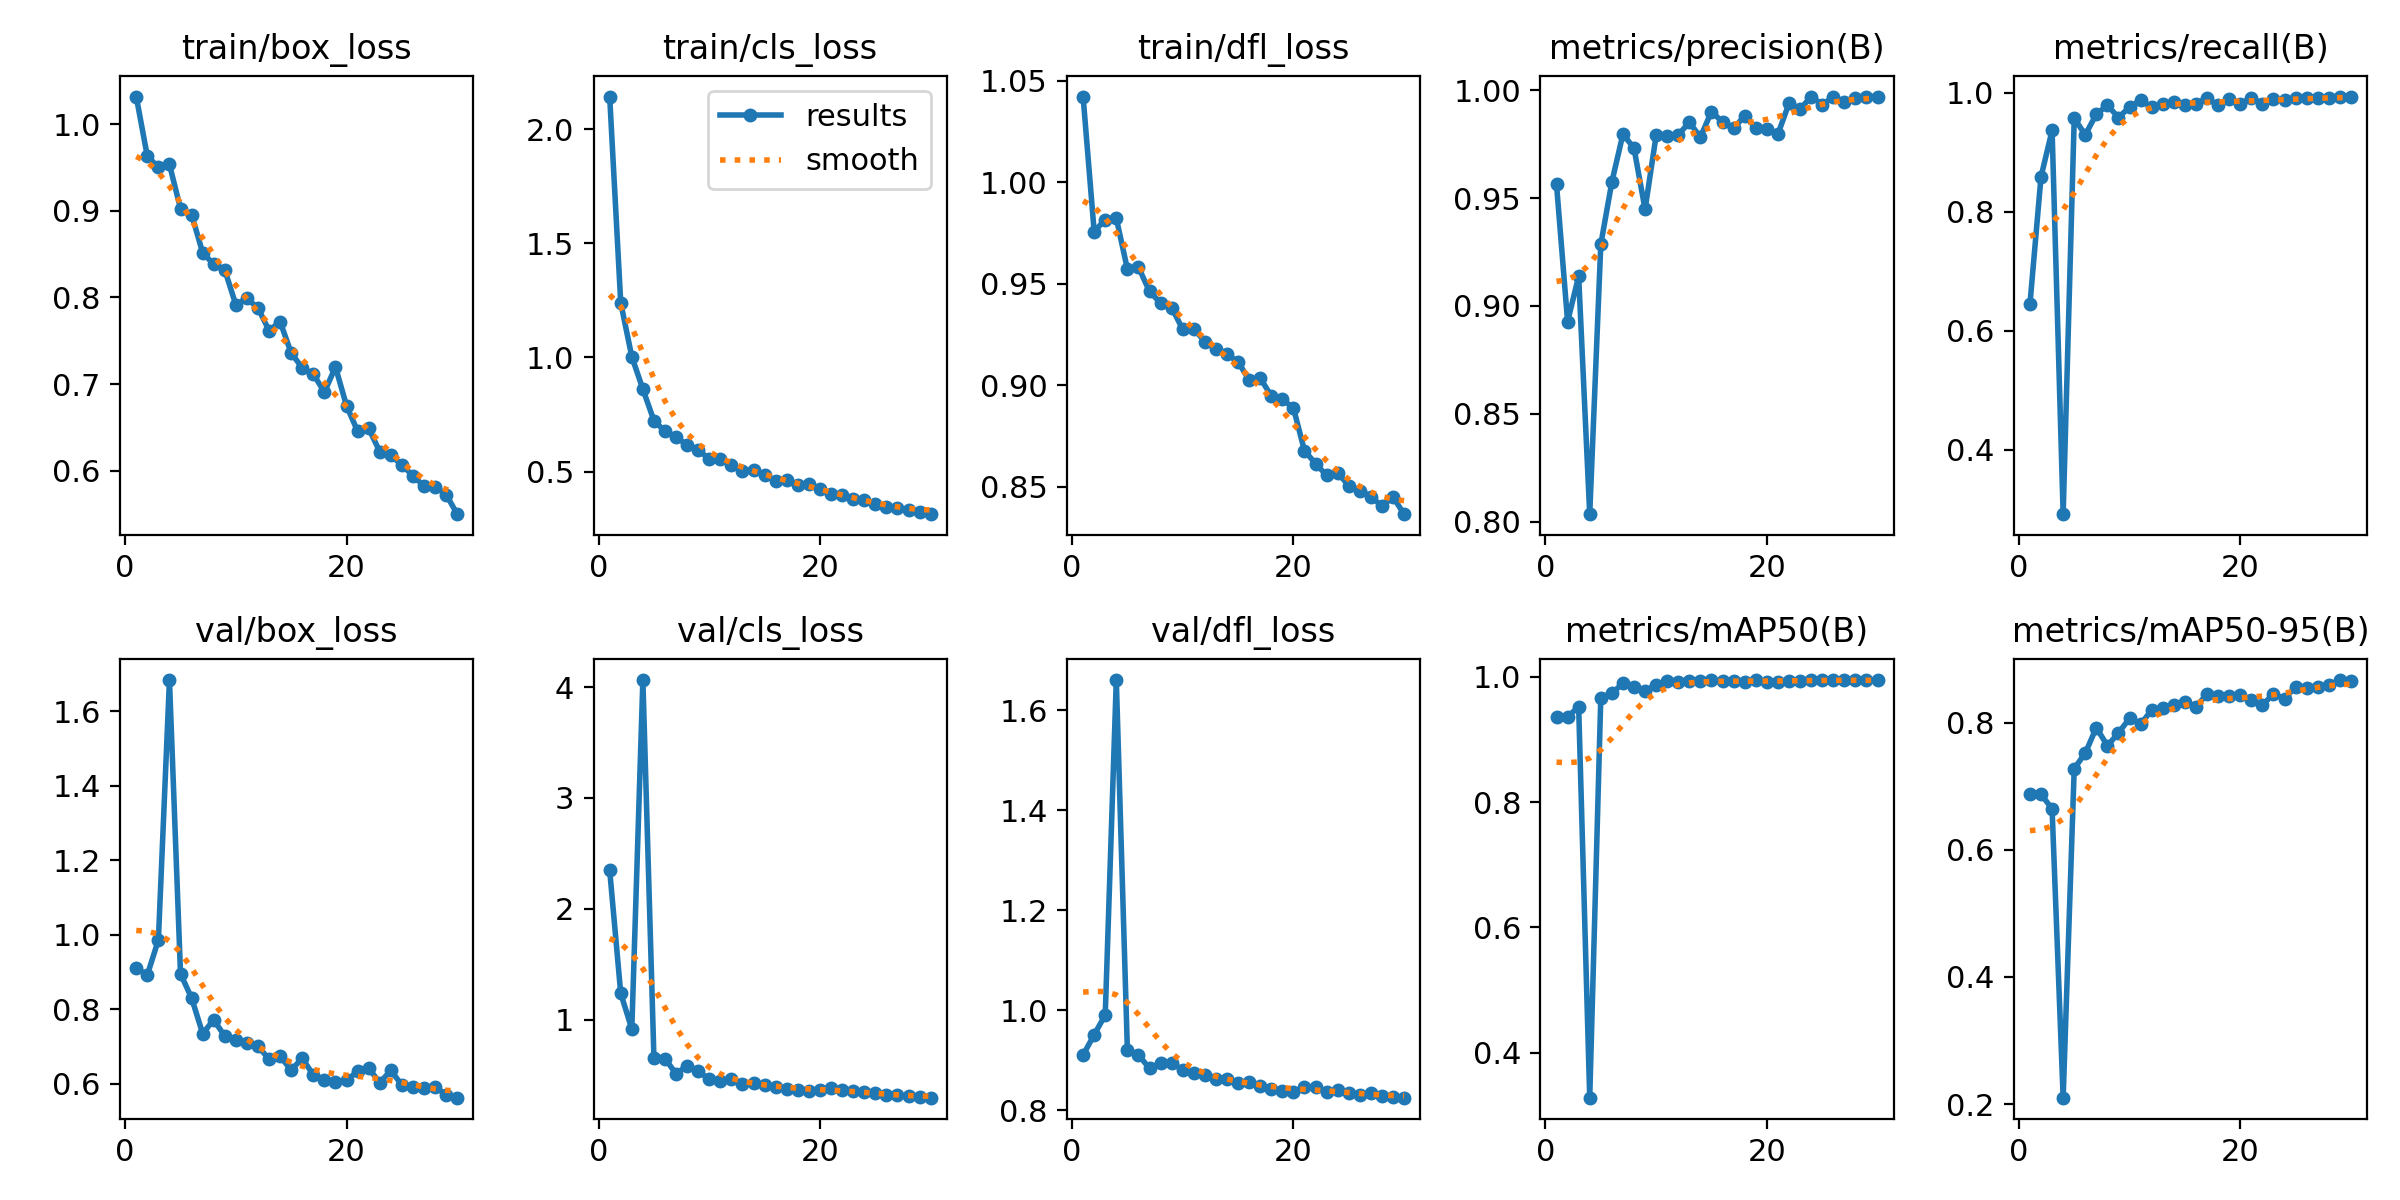

confusion_matrix.png


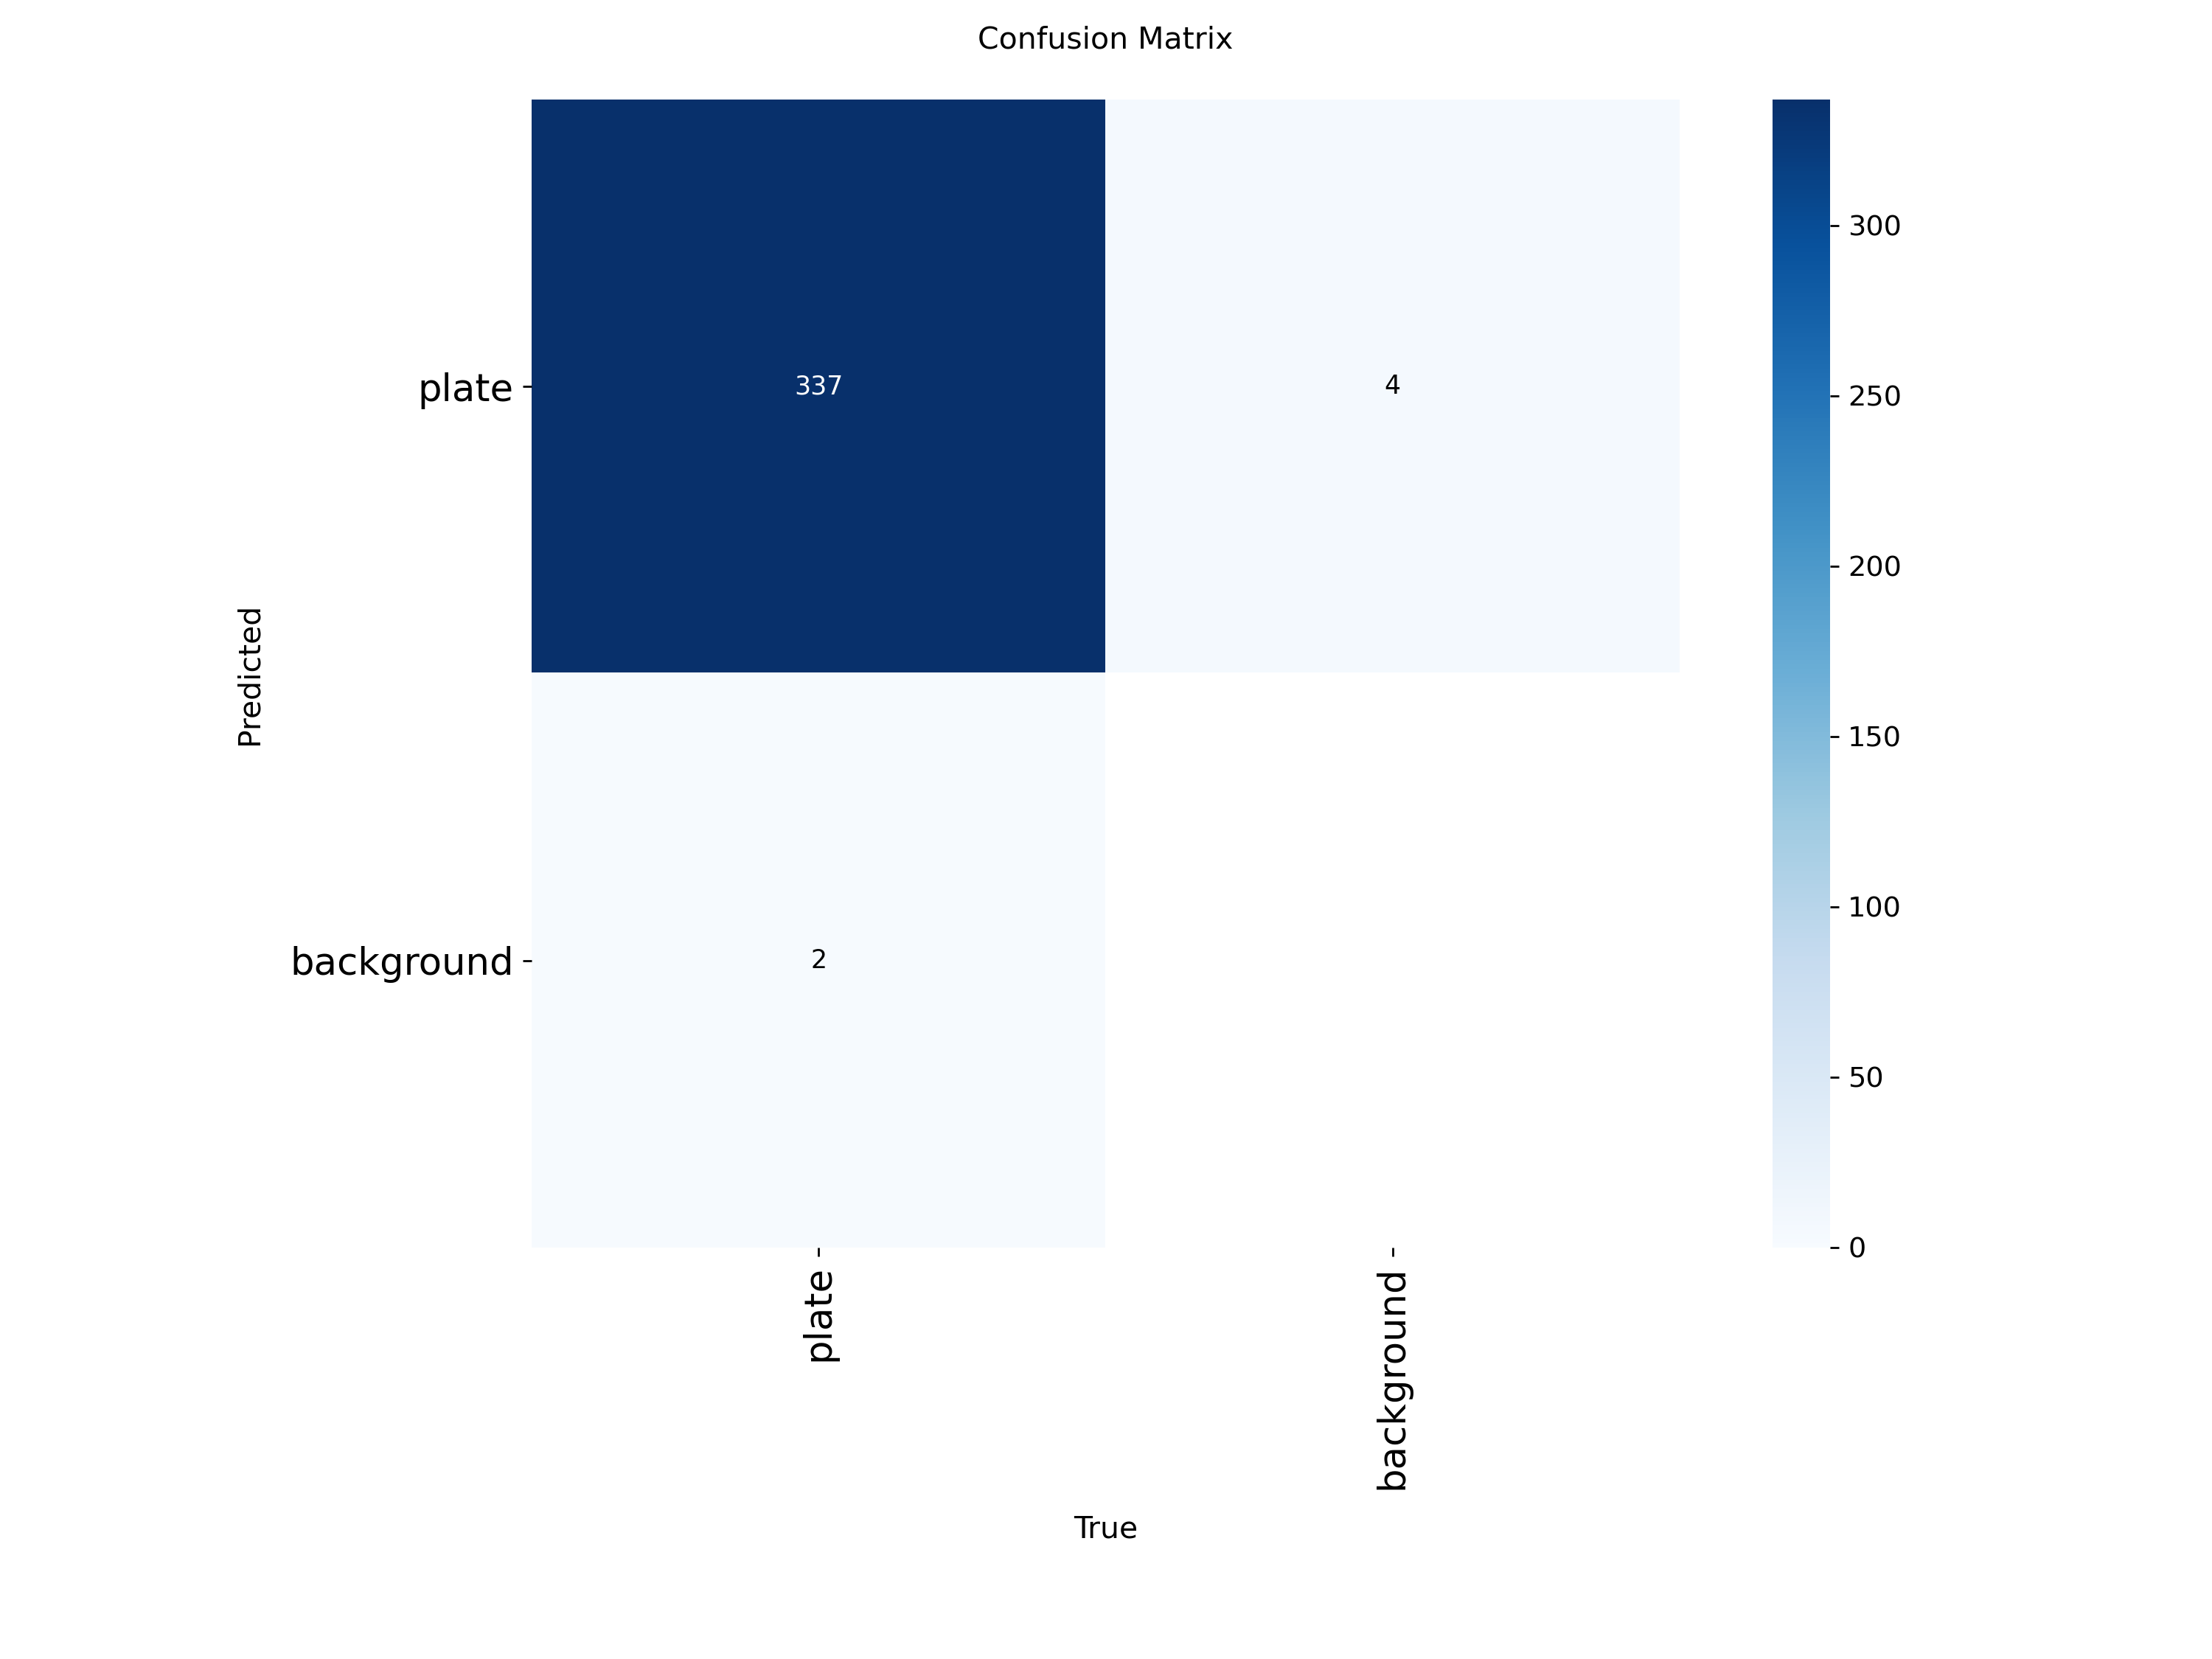

In [16]:
from IPython.display import Image, display
from pathlib import Path

result_dir = Path("/content/runs/detect/plate_train")

for name in [
    "results.png",
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
]:
    path = result_dir / name
    if path.exists():
        print(name)
        display(Image(filename=str(path)))


In [17]:
import pandas as pd

results_csv = "/content/runs/detect/plate_train/results.csv"
df = pd.read_csv(results_csv)
df.tail()


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
25,26,780.297,0.59406,0.34337,0.84817,0.99681,0.99115,0.99435,0.85440,0.59082,0.32014,0.82963,0.000350,0.000350,0.000350
26,27,807.088,0.58219,0.34157,0.84523,0.99468,0.99115,0.99420,0.85613,0.58890,0.31844,0.83330,0.000284,0.000284,0.000284
27,28,833.742,0.58138,0.33321,0.84045,0.99624,0.99115,0.99399,0.85914,0.59254,0.30923,0.82879,0.000218,0.000218,0.000218
28,29,860.430,0.57231,0.32383,0.84504,0.99704,0.99384,0.99447,0.86715,0.57009,0.29838,0.82599,0.000152,0.000152,0.000152
29,30,887.674,0.54969,0.31321,0.83654,0.99704,0.99403,0.99447,0.86555,0.56306,0.29619,0.82474,0.000086,0.000086,0.000086


In [18]:
from pathlib import Path

summary = """
YOLO Plate Detector Training Summary

Model: YOLO11n pretrained model
Training method: Transfer learning / fine-tuning
Dataset: Kaggle Indian vehicle license plate dataset
Total annotated images: 1698
Train images: 1359
Validation images: 339
Epochs: 30
Image size: 640
Batch size: 16
Validation Precision: 0.997
Validation Recall: 0.994
Validation mAP50: 0.994
Validation mAP50-95: 0.867

Trained model:
runs/detect/plate_train/weights/best.pt

Use in project:
Replace local app best.pt with this trained best.pt.
"""

Path("/content/runs/detect/plate_train/TRAINING_SUMMARY.txt").write_text(summary)
print(summary)



YOLO Plate Detector Training Summary

Model: YOLO11n pretrained model
Training method: Transfer learning / fine-tuning
Dataset: Kaggle Indian vehicle license plate dataset
Total annotated images: 1698
Train images: 1359
Validation images: 339
Epochs: 30
Image size: 640
Batch size: 16
Validation Precision: 0.997
Validation Recall: 0.994
Validation mAP50: 0.994
Validation mAP50-95: 0.867

Trained model:
runs/detect/plate_train/weights/best.pt

Use in project:
Replace local app best.pt with this trained best.pt.



In [19]:
from google.colab import files

!zip -r /content/plate_train_results.zip /content/runs/detect/plate_train
files.download("/content/plate_train_results.zip")


updating: content/runs/detect/plate_train/ (stored 0%)
updating: content/runs/detect/plate_train/confusion_matrix_normalized.png (deflated 37%)
updating: content/runs/detect/plate_train/train_batch2.jpg (deflated 3%)
updating: content/runs/detect/plate_train/confusion_matrix.png (deflated 37%)
updating: content/runs/detect/plate_train/val_batch2_labels.jpg (deflated 8%)
updating: content/runs/detect/plate_train/val_batch0_pred.jpg (deflated 10%)
updating: content/runs/detect/plate_train/train_batch0.jpg (deflated 4%)
updating: content/runs/detect/plate_train/BoxF1_curve.png (deflated 18%)
updating: content/runs/detect/plate_train/args.yaml (deflated 54%)
updating: content/runs/detect/plate_train/train_batch1701.jpg (deflated 10%)
updating: content/runs/detect/plate_train/BoxPR_curve.png (deflated 30%)
updating: content/runs/detect/plate_train/val_batch0_labels.jpg (deflated 11%)
updating: content/runs/detect/plate_train/results.png (deflated 8%)
updating: content/runs/detect/plate_trai

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
!ls -lh /content/runs/detect/plate_train/weights/best.pt
!ls -lh /content/plate_train_results.zip


-rw-r--r-- 1 root root 5.2M May  1 09:58 /content/runs/detect/plate_train/weights/best.pt
-rw-r--r-- 1 root root 15M May  1 10:06 /content/plate_train_results.zip
